In [5]:
import os
import pickle
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

In [6]:
#folder = mt_classifications"
folder = "/home/lydiagk/obs_tremor/tremor_detection/c_classifications"
threshold = 100 

# organize by season
def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in[9, 10, 11]:
        return "Fall"

# load files from classifications folder
start_times = []
end_times = []

for file in os.listdir(folder):
    #if not file.endswith("classifications.pickle"):
        #continue

    filepath = os.path.join(folder, file)
    #print(f"Loading {filepath}")

    with open(filepath, "rb") as handle:
        data = pickle.load(handle)

    # Filter peaks and tremor detections
    peaks = [p for p in data if p[2] > 1]
    tremor = [c for c in peaks if c[4] > threshold]

    # Extract timestamps
    for tr in tremor:
        t1 = tr[0][0] 
        t2 = tr[0][1] 
        start_times.append(t1.datetime)
        end_times.append(t2.datetime)

#print(f"Total tremor detections: {len(times)}")

seasonal_dist = pd.DataFrame({"start_time": start_times})
seasonal_dist["end_time"] = end_times
seasonal_dist["month"] = seasonal_dist["start_time"].dt.month
seasonal_dist["season"] = seasonal_dist["month"].apply(month_to_season)

season_counts = seasonal_dist["season"].value_counts().sort_index()
season_counts


IndexError: list index out of range

"\nplt.hist(seasonal_dist['month'], bins= range(1,14), color='royalblue', edgecolor = 'k', align = 'left')\nplt.xticks(range(1,13))\nplt.xlabel('Month')\nplt.ylabel('Frequency')\nplt.title('Distribution of Tremor-like signals under 20 ratio')\n"

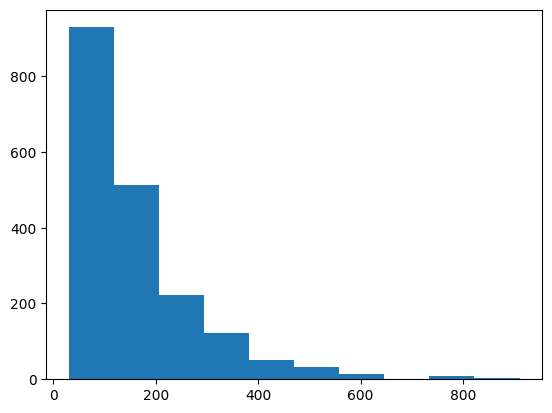

In [3]:
#display(seasonal_dist)

d = seasonal_dist["end_time"] - seasonal_dist["start_time"]
duration = d.dt.total_seconds()


plt.hist(duration)
'''
plt.hist(seasonal_dist['month'], bins= range(1,14), color='royalblue', edgecolor = 'k', align = 'left')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.title('Distribution of Tremor-like signals under 20 ratio')
'''

In [15]:
import os
print(os.getcwd())
file_name = 'overlaps_mt_10hz.pickle'
with open(file_name, 'rb') as handle:
    overlaps = pickle.load(handle)
#display(overlaps)

/home/lydiagk/mariana_tremor


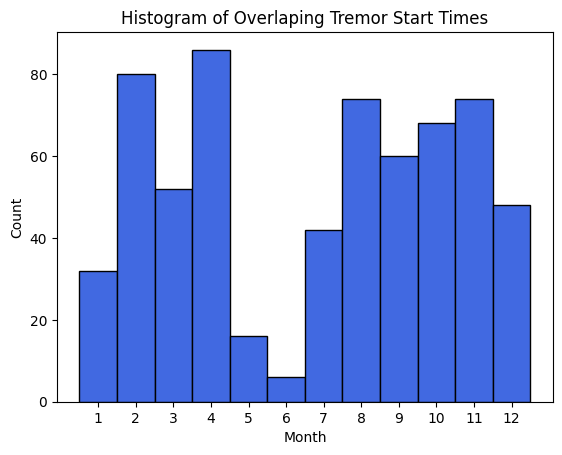

In [16]:
df = pd.DataFrame(overlaps)

df["start_a"] = df["window_a"].apply(lambda t: t[0].datetime)
df["start_b"] = df["window_b"].apply(lambda t: t[0].datetime)
#df["start_c"] = df["window_c"].apply(lambda t: t[0].datetime)


starts = pd.concat([df["start_a"],
                        df["start_b"]],
                        #df["start_c"]],
                        ignore_index=True)

months = starts.dt.month


plt.hist(months, bins=range(1,14), edgecolor='k', color='royalblue', align = 'left')
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Count")
plt.title("Histogram of Overlaping Tremor Start Times")
plt.show()